In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy import stats
from sklearn.linear_model import LinearRegression

In [3]:
plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

pd.set_option("display.float_format","{:.4f}".format)

In [4]:
fund = pd.read_csv("../data/processed/clean_fund_master.csv")

nav = pd.read_csv("../data/processed/clean_nav.csv")

performance = pd.read_csv("../data/processed/clean_performance.csv")

benchmark = pd.read_csv("../data/processed/clean_benchmark.csv")

In [5]:
print("="*60)

print("Fund Master :", fund.shape)

print("NAV History :", nav.shape)

print("Performance :", performance.shape)

print("Benchmark :", benchmark.shape)

print("="*60)

Fund Master : (40, 15)
NAV History : (46000, 3)
Performance : (40, 19)
Benchmark : (8050, 3)


In [6]:
fund.head()


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.5400,1.0000,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.6600,1.0000,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.4300,1.0000,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.7200,1.0000,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.7700,0.0000,500,1000,Dinesh Ahuja,Low,DC02


In [7]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.4200,12.3600,14.4500,11.4900,0.8700,0.8900,0.8800,1.2900,14.0000,-21.7000,14288,1.5400,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.2500,11.3000,14.2300,9.5200,1.7800,0.8700,0.8100,1.2900,14.0000,-24.4300,1231,0.6600,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.5600,23.3900,20.6700,22.1600,1.2300,0.8900,0.9400,1.3500,25.0000,-13.3500,19259,1.4300,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.5900,23.1400,21.8200,22.0100,1.1300,1.0400,0.9300,1.6700,25.0000,-24.7800,36061,0.7200,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.3400,6.0700,5.4300,4.4700,1.6000,0.2200,1.5200,2.1100,4.0000,-2.3000,24101,0.7700,5,Low


In [9]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.7900
1,2022-01-04,NIFTY50,17689.6400
2,2022-01-05,NIFTY50,17835.0500
3,2022-01-06,NIFTY50,17878.5100
4,2022-01-07,NIFTY50,17759.1500


In [10]:
print("="*70)
print("Fund Master")
print("="*70)

fund.info()

print("\n")

print("="*70)
print("NAV")
print("="*70)

nav.info()

print("\n")

print("="*70)
print("Performance")
print("="*70)

performance.info()

print("\n")

print("="*70)
print("Benchmark")
print("="*70)

benchmark.info()

Fund Master
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB


NA

In [11]:
print("="*70)
print("Missing Values")
print("="*70)

print("\nFund Master")

print(fund.isnull().sum())

print("\nNAV")

print(nav.isnull().sum())

print("\nPerformance")

print(performance.isnull().sum())

print("\nBenchmark")

print(benchmark.isnull().sum())

Missing Values

Fund Master
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

NAV
amfi_code    0
date         0
nav          0
dtype: int64

Performance
amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64

Benchmark
date           0
index_name     0
close_val

In [12]:
print(nav.dtypes)

print(performance.dtypes)

print(benchmark.dtypes)

amfi_code      int64
date             str
nav          float64
dtype: object
amfi_code               int64
scheme_name               str
fund_house                str
category                  str
plan                      str
return_1yr_pct        float64
return_3yr_pct        float64
return_5yr_pct        float64
benchmark_3yr_pct     float64
alpha                 float64
beta                  float64
sharpe_ratio          float64
sortino_ratio         float64
std_dev_ann_pct       float64
max_drawdown_pct      float64
aum_crore               int64
expense_ratio_pct     float64
morningstar_rating      int64
risk_grade                str
dtype: object
date               str
index_name         str
close_value    float64
dtype: object


In [13]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [14]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

benchmark = benchmark.sort_values(
    "date"
)

In [15]:
print("NAV Date Range")

print(nav["date"].min())

print(nav["date"].max())

print()

print("Benchmark Date Range")

print(benchmark["date"].min())

print(benchmark["date"].max())

NAV Date Range
2022-01-03 00:00:00
2026-05-29 00:00:00

Benchmark Date Range
2022-01-03 00:00:00
2026-05-29 00:00:00


In [16]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [17]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.0103
2,100016,2022-01-05,521.7239,0.0129
3,100016,2022-01-06,515.7880,-0.0114
4,100016,2022-01-07,515.1639,-0.0012
5,100016,2022-01-10,510.7136,-0.0086
6,100016,2022-01-11,513.5542,0.0056
7,100016,2022-01-12,512.3195,-0.0024
8,100016,2022-01-13,510.2445,-0.0041
9,100016,2022-01-14,514.3636,0.0081


In [18]:
print(nav["daily_return"].isna().sum())

40


In [19]:
returns = nav.dropna(subset=["daily_return"]).copy()

In [20]:
print("Original NAV Records :", len(nav))
print("Return Records       :", len(returns))

Original NAV Records : 46000
Return Records       : 45960


In [21]:
returns["daily_return"].describe()

count   45960.0000
mean        0.0006
std         0.0103
min        -0.0581
25%        -0.0050
50%         0.0003
75%         0.0063
max         0.0647
Name: daily_return, dtype: float64

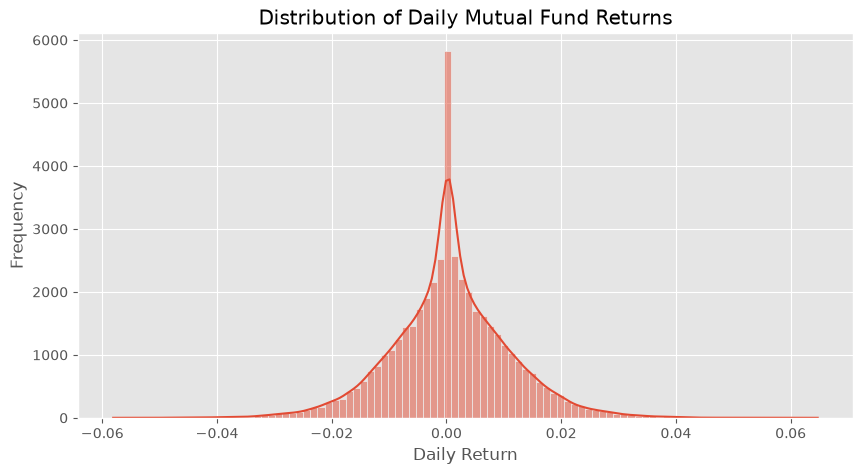

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    returns["daily_return"],
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Mutual Fund Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [24]:
returns = returns.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [25]:
returns.nlargest(
    10,
    "daily_return"
)[["scheme_name","date","daily_return"]]

,scheme_name,date,daily_return
24723,SBI Small Cap Fund - Regular Plan - Growth,2024-04-15,0.0647
13214,Nippon India Small Cap Fund - Regular - Growth,2024-03-19,0.0593
5202,ABSL Small Cap Fund - Regular - Growth,2024-05-01,0.0549
25543,SBI Small Cap Fund - Direct Plan - Growth,2023-01-10,0.0533
25809,SBI Small Cap Fund - Direct Plan - Growth,2024-01-17,0.0518
24133,SBI Small Cap Fund - Regular Plan - Growth,2022-01-10,0.0511
24349,SBI Small Cap Fund - Regular Plan - Growth,2022-11-08,0.0491
45042,DSP Small Cap Fund - Regular - Growth,2022-11-23,0.0485
24334,SBI Small Cap Fund - Regular Plan - Growth,2022-10-18,0.0485
25069,SBI Small Cap Fund - Regular Plan - Growth,2025-08-12,0.0471


In [26]:
returns.nsmallest(
    10,
    "daily_return"
)[["scheme_name","date","daily_return"]]

,scheme_name,date,daily_return
12762,Nippon India Small Cap Fund - Regular - Growth,2022-06-24,-0.0581
4912,ABSL Small Cap Fund - Regular - Growth,2023-03-22,-0.0518
12940,Nippon India Small Cap Fund - Regular - Growth,2023-03-01,-0.0503
45272,DSP Small Cap Fund - Regular - Growth,2023-10-11,-0.0489
5555,ABSL Small Cap Fund - Regular - Growth,2025-09-08,-0.0486
19786,Axis Small Cap Fund - Regular - Growth,2022-12-23,-0.0484
13321,Nippon India Small Cap Fund - Regular - Growth,2024-08-15,-0.0483
20289,Axis Small Cap Fund - Regular - Growth,2024-11-27,-0.0465
26025,SBI Small Cap Fund - Direct Plan - Growth,2024-11-14,-0.0454
38486,HDFC Mid-Cap Opportunities Fund - Direct - Growth,2024-03-11,-0.0452


In [27]:
returns.to_csv(
    "../reports/returns_computed.csv",
    index=False
)

print("returns_computed.csv saved successfully.")

returns_computed.csv saved successfully.


## Conclusion

Daily returns have been calculated and exported successfully. These return series provide the foundation for evaluating fund performance through annualized return, volatility, Sharpe ratio, CAGR, alpha, beta, and benchmark comparison in the following sections.

In [28]:
fund_returns = (
    returns
    .groupby("amfi_code")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        start_nav=("nav", "first"),
        end_nav=("nav", "last")
    )
    .reset_index()
)

fund_returns["years"] = (
    (fund_returns["end_date"] - fund_returns["start_date"])
    .dt.days / 365.25
)

fund_returns["annualized_return_pct"] = (
    (
        fund_returns["end_nav"] / fund_returns["start_nav"]
    ) ** (1 / fund_returns["years"]) - 1
) * 100

In [29]:
volatility = (
    returns
    .groupby("amfi_code")["daily_return"]
    .std()
    .mul(np.sqrt(252))
    .mul(100)
    .reset_index(name="volatility_pct")
)

In [30]:
performance_metrics = fund_returns.merge(
    volatility,
    on="amfi_code",
    how="left"
)

In [31]:
performance_metrics = performance_metrics.merge(
    fund[[
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "sub_category",
        "plan"
    ]],
    on="amfi_code",
    how="left"
)

In [32]:
performance_metrics[
    [
        "scheme_name",
        "category",
        "plan",
        "annualized_return_pct",
        "volatility_pct"
    ]
].sort_values(
    "annualized_return_pct",
    ascending=False
).head(10)

,scheme_name,category,plan,annualized_return_pct,volatility_pct
25,ICICI Pru Midcap Fund - Regular - Growth,Equity,Regular,33.4596,19.2909
21,SBI Small Cap Fund - Regular Plan - Growth,Equity,Regular,32.8946,25.1406
39,DSP Small Cap Fund - Regular - Growth,Equity,Regular,32.6284,24.8402
36,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,Regular,31.7221,17.6740
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Regular,30.5422,18.9367
34,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Regular,30.4273,14.1937
30,Kotak Flexicap Fund - Regular - Growth,Equity,Regular,30.3946,15.8870
38,DSP Midcap Fund - Regular - Growth,Equity,Regular,29.5878,17.7462
16,Axis Midcap Fund - Regular - Growth,Equity,Regular,28.3394,19.4071
19,SBI Bluechip Fund - Regular Plan - Growth,Equity,Regular,25.8428,13.7414


In [34]:
top10_return = performance_metrics.nlargest(
    10,
    "annualized_return_pct"
)

top10_return[
    [
        "scheme_name",
        "annualized_return_pct",
        "volatility_pct"
    ]
]

,scheme_name,annualized_return_pct,volatility_pct
25,ICICI Pru Midcap Fund - Regular - Growth,33.4596,19.2909
21,SBI Small Cap Fund - Regular Plan - Growth,32.8946,25.1406
39,DSP Small Cap Fund - Regular - Growth,32.6284,24.8402
36,Mirae Asset Tax Saver Fund - Regular - Growth,31.7221,17.6740
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,30.5422,18.9367
34,Mirae Asset Large Cap Fund - Regular - Growth,30.4273,14.1937
30,Kotak Flexicap Fund - Regular - Growth,30.3946,15.8870
38,DSP Midcap Fund - Regular - Growth,29.5878,17.7462
16,Axis Midcap Fund - Regular - Growth,28.3394,19.4071
19,SBI Bluechip Fund - Regular Plan - Growth,25.8428,13.7414


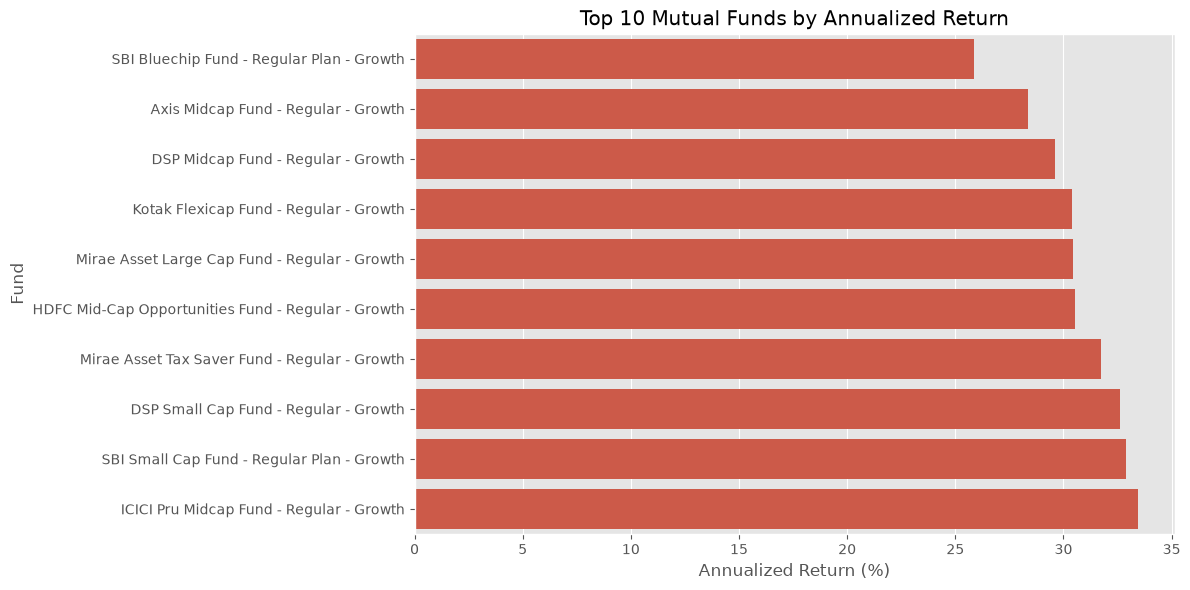

In [35]:
plt.figure(figsize=(12,6))

plot_data = top10_return.sort_values(
    "annualized_return_pct"
)

sns.barplot(
    data=plot_data,
    x="annualized_return_pct",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by Annualized Return")

plt.xlabel("Annualized Return (%)")
plt.ylabel("Fund")

plt.tight_layout()
plt.show()

In [36]:
top10_volatility = performance_metrics.nlargest(
    10,
    "volatility_pct"
)

top10_volatility[
    [
        "scheme_name",
        "category",
        "volatility_pct",
        "annualized_return_pct"
    ]
]

,scheme_name,category,volatility_pct,annualized_return_pct
4,ABSL Small Cap Fund - Regular - Growth,Equity,25.7973,8.2124
11,Nippon India Small Cap Fund - Regular - Growth,Equity,25.2415,16.4819
21,SBI Small Cap Fund - Regular Plan - Growth,Equity,25.1406,32.8946
17,Axis Small Cap Fund - Regular - Growth,Equity,25.0666,1.0943
22,SBI Small Cap Fund - Direct Plan - Growth,Equity,24.9501,2.4952
39,DSP Small Cap Fund - Regular - Growth,Equity,24.8402,32.6284
16,Axis Midcap Fund - Regular - Growth,Equity,19.4071,28.3394
25,ICICI Pru Midcap Fund - Regular - Growth,Equity,19.2909,33.4596
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,18.9367,30.5422
33,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,18.3524,11.4365


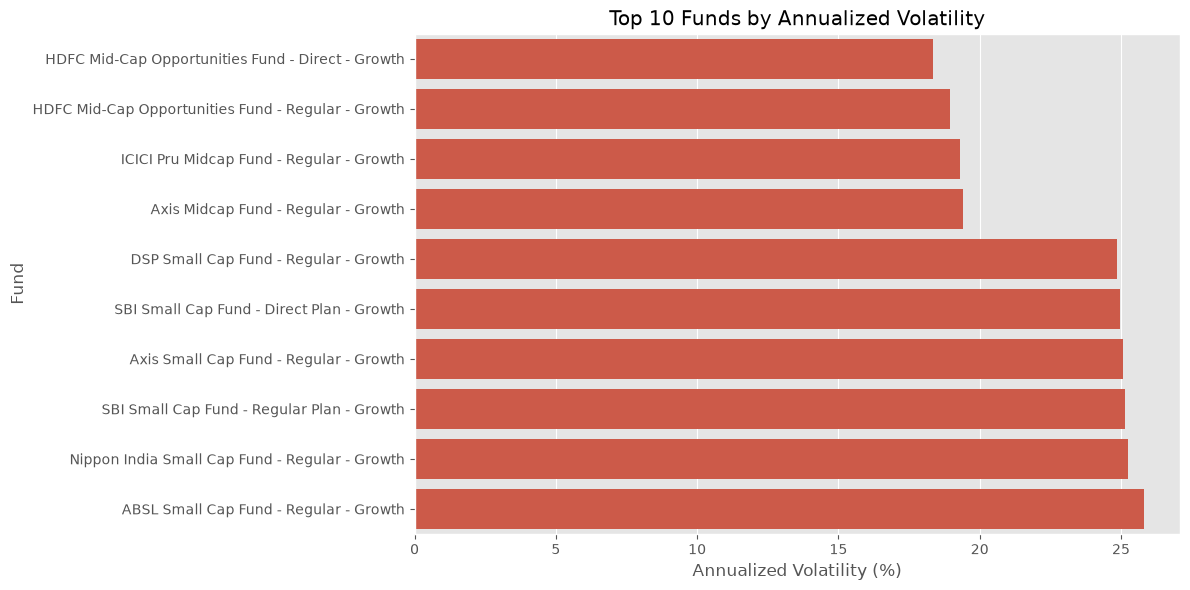

In [37]:
plt.figure(figsize=(12,6))

plot_data = top10_volatility.sort_values(
    "volatility_pct"
)

sns.barplot(
    data=plot_data,
    x="volatility_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by Annualized Volatility")

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Fund")

plt.tight_layout()
plt.show()

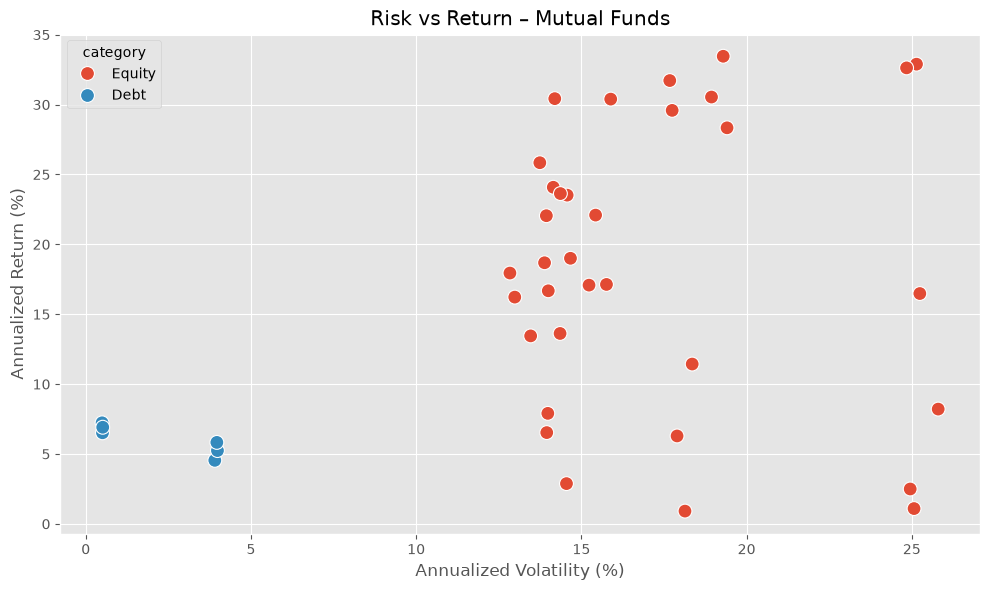

In [38]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance_metrics,
    x="volatility_pct",
    y="annualized_return_pct",
    hue="category",
    s=100
)

plt.title("Risk vs Return – Mutual Funds")

plt.xlabel("Annualized Volatility (%)")

plt.ylabel("Annualized Return (%)")

plt.tight_layout()
plt.show()

In [39]:
performance_metrics[
    [
        "scheme_name",
        "category",
        "annualized_return_pct",
        "volatility_pct"
    ]
].sort_values(
    "annualized_return_pct",
    ascending=False
).head(10)

,scheme_name,category,annualized_return_pct,volatility_pct
25,ICICI Pru Midcap Fund - Regular - Growth,Equity,33.4596,19.2909
21,SBI Small Cap Fund - Regular Plan - Growth,Equity,32.8946,25.1406
39,DSP Small Cap Fund - Regular - Growth,Equity,32.6284,24.8402
36,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,31.7221,17.6740
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,30.5422,18.9367
34,Mirae Asset Large Cap Fund - Regular - Growth,Equity,30.4273,14.1937
30,Kotak Flexicap Fund - Regular - Growth,Equity,30.3946,15.8870
38,DSP Midcap Fund - Regular - Growth,Equity,29.5878,17.7462
16,Axis Midcap Fund - Regular - Growth,Equity,28.3394,19.4071
19,SBI Bluechip Fund - Regular Plan - Growth,Equity,25.8428,13.7414


## Conclusion

Annualized return and volatility have been calculated for all mutual fund schemes using their historical daily NAV data.


In [64]:
print("NAV Start Date :", nav["date"].min())
print("NAV End Date   :", nav["date"].max())

NAV Start Date : 2022-01-03 00:00:00
NAV End Date   : 2026-05-29 00:00:00


In [65]:
def calculate_cagr(nav_data, years):
    
    end_date = nav_data["date"].max()
    start_target = end_date - pd.DateOffset(years=years)
    
    results = []
    
    for amfi_code, group in nav_data.groupby("amfi_code"):
        
        group = group.sort_values("date")
        
        start_data = group[group["date"] >= start_target]
        
        if len(start_data) == 0:
            continue
        
        start_row = start_data.iloc[0]
        end_row = group.iloc[-1]
        
        actual_years = (
            end_row["date"] - start_row["date"]
        ).days / 365.25
        
        if actual_years <= 0:
            continue
        
        cagr = (
            (end_row["nav"] / start_row["nav"])
            ** (1 / actual_years)
            - 1
        ) * 100
        
        results.append({
            "amfi_code": amfi_code,
            "start_date": start_row["date"],
            "end_date": end_row["date"],
            "start_nav": start_row["nav"],
            "end_nav": end_row["nav"],
            "cagr_pct": cagr
        })
    
    return pd.DataFrame(results)

In [66]:
cagr_1yr = calculate_cagr(nav, 1)

cagr_1yr = cagr_1yr.rename(
    columns={"cagr_pct": "cagr_1yr_pct"}
)

print("1-Year CAGR calculated for:", len(cagr_1yr), "funds")

1-Year CAGR calculated for: 40 funds


In [67]:
cagr_3yr = calculate_cagr(nav, 3)

cagr_3yr = cagr_3yr.rename(
    columns={"cagr_pct": "cagr_3yr_pct"}
)

print("3-Year CAGR calculated for:", len(cagr_3yr), "funds")

3-Year CAGR calculated for: 40 funds


In [68]:
cagr_5yr = calculate_cagr(nav, 5)

cagr_5yr = cagr_5yr.rename(
    columns={"cagr_pct": "cagr_5yr_pct"}
)

print("5-Year CAGR calculated for:", len(cagr_5yr), "funds")

5-Year CAGR calculated for: 40 funds


In [69]:
cagr_table = cagr_1yr[
    ["amfi_code", "cagr_1yr_pct"]
].merge(
    cagr_3yr[
        ["amfi_code", "cagr_3yr_pct"]
    ],
    on="amfi_code",
    how="outer"
).merge(
    cagr_5yr[
        ["amfi_code", "cagr_5yr_pct"]
    ],
    on="amfi_code",
    how="outer"
)

In [70]:
cagr_table = cagr_table.merge(
    fund[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "sub_category",
            "plan"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [71]:
cagr_table = cagr_table[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "sub_category",
        "plan",
        "cagr_1yr_pct",
        "cagr_3yr_pct",
        "cagr_5yr_pct"
    ]
]

In [72]:
cagr_table = cagr_table[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "sub_category",
        "plan",
        "cagr_1yr_pct",
        "cagr_3yr_pct",
        "cagr_5yr_pct"
    ]
]

In [73]:
cagr_table.sort_values(
    "cagr_3yr_pct",
    ascending=False
).head(10)

,amfi_code,scheme_name,fund_house,category,sub_category,plan,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,Mid Cap,Regular,22.2779,35.1025,28.2144
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Large Cap,Regular,20.3760,33.9920,30.9741
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,Large Cap,Direct,13.0738,32.4789,23.2951
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Mid Cap,Regular,53.2772,32.4340,30.1232
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,Mid Cap,Regular,29.6277,31.7692,32.8274
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Large Cap,Regular,60.4893,30.4486,25.8047
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Flexi Cap,Regular,26.6776,29.5751,30.9075
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,ELSS,Regular,39.7838,29.1714,31.9495
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Large Cap,Regular,47.9638,28.9602,23.5384
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,Small Cap,Regular,65.1955,26.9935,32.2874


In [74]:
cagr_table[
    [
        "cagr_1yr_pct",
        "cagr_3yr_pct",
        "cagr_5yr_pct"
    ]
] = cagr_table[
    [
        "cagr_1yr_pct",
        "cagr_3yr_pct",
        "cagr_5yr_pct"
    ]
].round(2)

In [75]:
top10_cagr = cagr_table.nlargest(
    10,
    "cagr_3yr_pct"
)

top10_cagr[
    [
        "scheme_name",
        "category",
        "plan",
        "cagr_1yr_pct",
        "cagr_3yr_pct",
        "cagr_5yr_pct"
    ]
]

,scheme_name,category,plan,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
16,Axis Midcap Fund - Regular - Growth,Equity,Regular,22.2800,35.1000,28.2100
34,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Regular,20.3800,33.9900,30.9700
24,ICICI Pru Bluechip Fund - Direct - Growth,Equity,Direct,13.0700,32.4800,23.3000
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Regular,53.2800,32.4300,30.1200
25,ICICI Pru Midcap Fund - Regular - Growth,Equity,Regular,29.6300,31.7700,32.8300
19,SBI Bluechip Fund - Regular Plan - Growth,Equity,Regular,60.4900,30.4500,25.8000
30,Kotak Flexicap Fund - Regular - Growth,Equity,Regular,26.6800,29.5800,30.9100
36,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,Regular,39.7800,29.1700,31.9500
3,ABSL Frontline Equity Fund - Regular - Growth,Equity,Regular,47.9600,28.9600,23.5400
39,DSP Small Cap Fund - Regular - Growth,Equity,Regular,65.2000,26.9900,32.2900


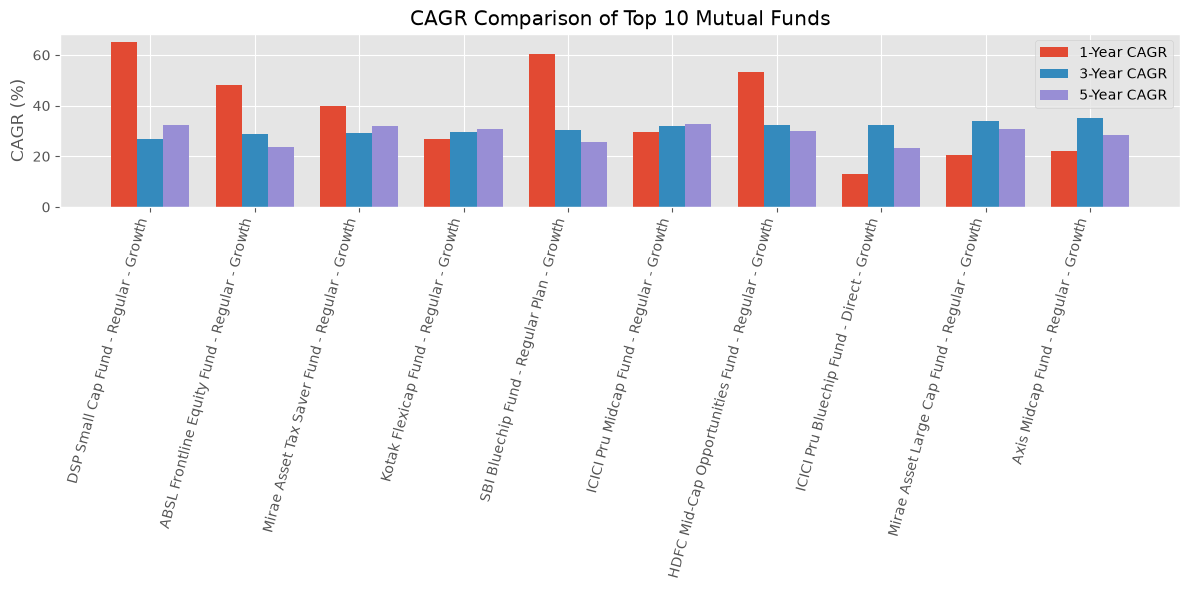

In [76]:
plot_data = top10_cagr.sort_values(
    "cagr_3yr_pct"
)

plt.figure(figsize=(12, 6))

x = np.arange(len(plot_data))
width = 0.25

plt.bar(
    x - width,
    plot_data["cagr_1yr_pct"],
    width,
    label="1-Year CAGR"
)

plt.bar(
    x,
    plot_data["cagr_3yr_pct"],
    width,
    label="3-Year CAGR"
)

plt.bar(
    x + width,
    plot_data["cagr_5yr_pct"],
    width,
    label="5-Year CAGR"
)

plt.xticks(
    x,
    plot_data["scheme_name"],
    rotation=75,
    ha="right"
)

plt.ylabel("CAGR (%)")
plt.title("CAGR Comparison of Top 10 Mutual Funds")

plt.legend()

plt.tight_layout()

plt.show()

In [77]:
print(
    cagr_table[
        [
            "scheme_name",
            "cagr_3yr_pct"
        ]
    ]
    .sort_values(
        "cagr_3yr_pct",
        ascending=False
    )
    .to_string(index=False)
)

                                          scheme_name  cagr_3yr_pct
                  Axis Midcap Fund - Regular - Growth       35.1000
        Mirae Asset Large Cap Fund - Regular - Growth       33.9900
            ICICI Pru Bluechip Fund - Direct - Growth       32.4800
   HDFC Mid-Cap Opportunities Fund - Regular - Growth       32.4300
             ICICI Pru Midcap Fund - Regular - Growth       31.7700
            SBI Bluechip Fund - Regular Plan - Growth       30.4500
               Kotak Flexicap Fund - Regular - Growth       29.5800
        Mirae Asset Tax Saver Fund - Regular - Growth       29.1700
        ABSL Frontline Equity Fund - Regular - Growth       28.9600
                DSP Small Cap Fund - Regular - Growth       26.9900
                   DSP Midcap Fund - Regular - Growth       26.8600
           SBI Small Cap Fund - Regular Plan - Growth       26.6600
                UTI Flexi Cap Fund - Regular - Growth       25.5500
       Nippon India Large Cap Fund - Regular - G

In [78]:
performance_metrics = performance_metrics.drop(
    columns=[
        "cagr_1yr_pct",
        "cagr_3yr_pct",
        "cagr_5yr_pct"
    ],
    errors="ignore"
)

performance_metrics = performance_metrics.merge(
    cagr_table[
        [
            "amfi_code",
            "cagr_1yr_pct",
            "cagr_3yr_pct",
            "cagr_5yr_pct"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [79]:
performance_metrics[
    [
        "scheme_name",
        "cagr_1yr_pct",
        "cagr_3yr_pct",
        "cagr_5yr_pct"
    ]
].head()

,scheme_name,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
0,HDFC Top 100 Fund - Regular Plan - Growth,-2.2300,1.2900,2.6400
1,HDFC Short Term Debt Fund - Regular - Growth,3.7100,3.9200,4.4600
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.2800,32.4300,30.1200
3,ABSL Frontline Equity Fund - Regular - Growth,47.9600,28.9600,23.5400
4,ABSL Small Cap Fund - Regular - Growth,-24.0000,-4.1500,7.9400


## CAGR Conclusion

The 1-year, 3-year and 5-year CAGR values have been calculated for the mutual fund schemes using their historical NAV data.

The 3-year CAGR will receive a 30% weight in the final fund scorecard.

The next section calculates the Sharpe Ratio using the required 6.5% risk-free rate proxy.

In [81]:
RISK_FREE_RATE = 6.5

print("Assumed Annual Risk-Free Rate:", RISK_FREE_RATE, "%")

Assumed Annual Risk-Free Rate: 6.5 %


In [82]:
rf_annual = RISK_FREE_RATE / 100

print("Risk-Free Rate (decimal):", rf_annual)

Risk-Free Rate (decimal): 0.065


In [83]:
sharpe_data = (
    returns
    .groupby("amfi_code")
    .agg(
        mean_daily_return=("daily_return", "mean"),
        daily_volatility=("daily_return", "std")
    )
    .reset_index()
)

sharpe_data["annualized_return"] = (
    sharpe_data["mean_daily_return"] * 252
)

sharpe_data["annualized_volatility"] = (
    sharpe_data["daily_volatility"] * np.sqrt(252)
)

sharpe_data["sharpe_ratio"] = (
    (
        sharpe_data["annualized_return"]
        - rf_annual
    )
    /
    sharpe_data["annualized_volatility"]
)

In [84]:
sharpe_data = (
    returns
    .groupby("amfi_code")
    .agg(
        mean_daily_return=("daily_return", "mean"),
        daily_volatility=("daily_return", "std")
    )
    .reset_index()
)

sharpe_data["annualized_return"] = (
    sharpe_data["mean_daily_return"] * 252
)

sharpe_data["annualized_volatility"] = (
    sharpe_data["daily_volatility"] * np.sqrt(252)
)

sharpe_data["sharpe_ratio"] = (
    (
        sharpe_data["annualized_return"]
        - rf_annual
    )
    /
    sharpe_data["annualized_volatility"]
)

In [85]:
sharpe_data = sharpe_data.merge(
    fund[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [86]:
sharpe_data["sharpe_rank"] = (
    sharpe_data["sharpe_ratio"]
    .rank(
        ascending=False,
        method="min"
    )
)

In [87]:
sharpe_table = sharpe_data[
    [
        "scheme_name",
        "fund_house",
        "category",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "sharpe_rank"
    ]
].sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_table

,scheme_name,fund_house,category,annualized_return,annualized_volatility,sharpe_ratio,sharpe_rank
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.2706,0.1419,1.4483,1.0000
30,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.2726,0.1589,1.3067,2.0000
36,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.2833,0.1767,1.2349,3.0000
19,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.2310,0.1374,1.2083,4.0000
25,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.2927,0.1929,1.1801,5.0000
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.2659,0.1775,1.1321,6.0000
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.2721,0.1894,1.0937,7.0000
9,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,0.2180,0.1415,1.0817,8.0000
3,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.2146,0.1457,1.0272,9.0000
24,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.2124,0.1436,1.0265,10.0000


In [88]:
print("Number of funds:", len(sharpe_table))

Number of funds: 40


In [89]:
sharpe_table.head(10)

,scheme_name,fund_house,category,annualized_return,annualized_volatility,sharpe_ratio,sharpe_rank
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.2706,0.1419,1.4483,1.0000
30,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.2726,0.1589,1.3067,2.0000
36,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.2833,0.1767,1.2349,3.0000
19,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.2310,0.1374,1.2083,4.0000
25,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.2927,0.1929,1.1801,5.0000
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.2659,0.1775,1.1321,6.0000
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.2721,0.1894,1.0937,7.0000
9,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,0.2180,0.1415,1.0817,8.0000
3,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.2146,0.1457,1.0272,9.0000
24,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.2124,0.1436,1.0265,10.0000


In [90]:
performance_metrics = performance_metrics.drop(
    columns=["sharpe_ratio"],
    errors="ignore"
)

performance_metrics = performance_metrics.merge(
    sharpe_data[
        [
            "amfi_code",
            "sharpe_ratio",
            "sharpe_rank"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [91]:
performance_metrics[
    [
        "scheme_name",
        "sharpe_ratio",
        "sharpe_rank"
    ]
].head()

,scheme_name,sharpe_ratio,sharpe_rank
0,HDFC Top 100 Fund - Regular Plan - Growth,-0.2015,35.0000
1,HDFC Short Term Debt Fund - Regular - Growth,-0.5671,39.0000
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.0937,7.0000
3,ABSL Frontline Equity Fund - Regular - Growth,1.0272,9.0000
4,ABSL Small Cap Fund - Regular - Growth,0.1627,28.0000


## Sharpe Ratio Findings

The Sharpe Ratio was calculated for all 40 mutual fund schemes using a 6.5% annual risk-free rate, representing the RBI repo-rate proxy specified for this analysis.

Funds were ranked from highest to lowest Sharpe Ratio. A higher Sharpe Ratio indicates better risk-adjusted performance relative to total return volatility.

In [92]:
sortino_rows = []

for amfi_code, group in returns.groupby("amfi_code"):

    group = group.sort_values("date")

    daily_returns = group["daily_return"].dropna()

    mean_daily_return = daily_returns.mean()

    negative_returns = daily_returns[daily_returns < 0]

    downside_std = negative_returns.std()

    annualized_return = mean_daily_return * 252

    annualized_downside = downside_std * np.sqrt(252)

    sortino_ratio = (
        (annualized_return - rf_annual)
        / annualized_downside
    )

    sortino_rows.append({
        "amfi_code": amfi_code,
        "annualized_return": annualized_return,
        "downside_deviation": annualized_downside,
        "sortino_ratio": sortino_ratio
    })

sortino_data = pd.DataFrame(sortino_rows)

In [93]:
sortino_data = sortino_data.merge(
    fund[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [94]:
sortino_data = sortino_data.merge(
    fund[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [98]:
sortino_data["sortino_rank"] = (
    sortino_data["sortino_ratio"]
    .rank(
        ascending=False,
        method="min"
    )
)

In [103]:
sortino_data.columns



Index(['amfi_code', 'annualized_return', 'downside_deviation', 'sortino_ratio',
       'scheme_name_x', 'fund_house_x', 'category_x', 'scheme_name_y',
       'fund_house_y', 'category_y', 'sortino_rank'],
      dtype='str')

In [104]:
sortino_data = sortino_data.drop(
    columns=[
        "scheme_name_y",
        "fund_house_y",
        "category_y"
    ]
)

sortino_data = sortino_data.rename(
    columns={
        "scheme_name_x": "scheme_name",
        "fund_house_x": "fund_house",
        "category_x": "category"
    }
)

In [105]:
sortino_data.columns

Index(['amfi_code', 'annualized_return', 'downside_deviation', 'sortino_ratio',
       'scheme_name', 'fund_house', 'category', 'sortino_rank'],
      dtype='str')

In [106]:
sortino_table = sortino_data[
    [
        "scheme_name",
        "fund_house",
        "category",
        "annualized_return",
        "downside_deviation",
        "sortino_ratio",
        "sortino_rank"
    ]
].sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_table.head(10)

,scheme_name,fund_house,category,annualized_return,downside_deviation,sortino_ratio,sortino_rank
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.2706,0.0862,2.3856,1.0000
30,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.2726,0.0878,2.3643,2.0000
36,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.2833,0.1017,2.1469,3.0000
19,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.2310,0.0776,2.1403,4.0000
25,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.2927,0.1122,2.0294,5.0000
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.2659,0.1071,1.8751,6.0000
9,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,0.2180,0.0827,1.8501,7.0000
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.2721,0.1132,1.8291,8.0000
24,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.2124,0.0817,1.8053,9.0000
3,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.2146,0.0832,1.7996,10.0000


In [107]:
print("Number of funds:", len(sortino_table))
print("Missing Sortino:", sortino_table["sortino_ratio"].isna().sum())

Number of funds: 40
Missing Sortino: 0


## Sortino Ratio Finding

The Sortino Ratio ranks funds based on return relative to downside risk, with higher values indicating better risk-adjusted performance.

In [108]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',   'CRISIL_LIQUID', 'NIFTY_MIDCAP150',     'CRISIL_GILT',
        'NIFTY100',        'NIFTY500',    'BSE_SMALLCAP']
Length: 7, dtype: str

In [109]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.7900
5750,2022-01-03,CRISIL_LIQUID,2281.5100
2300,2022-01-03,NIFTY_MIDCAP150,9721.7900
6900,2022-01-03,CRISIL_GILT,1451.0600
1150,2022-01-03,NIFTY100,17778.2400


In [110]:
nifty100 = benchmark[
    benchmark["index_name"].str.replace(" ", "").str.upper() == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(nifty100["date"])

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100 = nifty100[
    ["date", "benchmark_return"]
].dropna()

nifty100.head()

,date,benchmark_return
1151,2022-01-04,-0.0135
1152,2022-01-05,0.0040
1153,2022-01-06,-0.0029
1154,2022-01-07,0.0062
1155,2022-01-10,-0.0084


In [113]:
import scipy
print(scipy.__version__)
from scipy.stats import linregress

1.17.1


In [114]:
alpha_beta_results = []

for amfi_code, group in returns.groupby("amfi_code"):

    fund_returns = group[
        ["date", "daily_return"]
    ].copy()

    fund_returns["date"] = pd.to_datetime(
        fund_returns["date"]
    )

    merged = fund_returns.merge(
        nifty100,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope

    daily_alpha = regression.intercept

    annualized_alpha = daily_alpha * 252

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": annualized_alpha,
        "beta": beta,
        "r_squared": regression.rvalue ** 2,
        "observations": len(merged)
    })

alpha_beta = pd.DataFrame(alpha_beta_results)

In [115]:
alpha_beta = alpha_beta.merge(
    fund[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [116]:
alpha_beta.shape

(40, 8)

In [117]:
alpha_beta_table = alpha_beta[
    [
        "scheme_name",
        "fund_house",
        "category",
        "alpha",
        "beta",
        "r_squared",
        "observations"
    ]
].sort_values(
    "alpha",
    ascending=False
)

alpha_beta_table.head(10)

,scheme_name,fund_house,category,alpha,beta,r_squared,observations
21,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.3034,-0.0232,0.0001,1149
39,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.3006,0.0115,0.0000,1149
25,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.2926,0.0005,0.0000,1149
36,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.2827,0.0181,0.0002,1149
30,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.2733,-0.0228,0.0003,1149
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.2720,0.0051,0.0000,1149
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.2698,0.0237,0.0005,1149
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.2660,-0.0025,0.0000,1149
16,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,0.2608,-0.0663,0.0019,1149
19,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.2320,-0.0318,0.0009,1149


In [118]:
print("Number of funds:", len(alpha_beta_table))
print("Missing Alpha:", alpha_beta_table["alpha"].isna().sum())
print("Missing Beta:", alpha_beta_table["beta"].isna().sum())

Number of funds: 40
Missing Alpha: 0
Missing Beta: 0


## Alpha and Beta Findings

Alpha measures benchmark-adjusted excess performance, while Beta measures sensitivity to NIFTY 100 market movements.

In [119]:
print(nifty100.shape)
print(nifty100["benchmark_return"].describe())

(1149, 2)
count   1149.0000
mean       0.0001
std        0.0081
min       -0.0269
25%       -0.0054
50%       -0.0001
75%        0.0055
max        0.0268
Name: benchmark_return, dtype: float64


In [120]:
test_fund = returns[
    returns["amfi_code"] == 119551
].copy()

test = test_fund[
    ["date", "daily_return"]
].merge(
    nifty100,
    on="date",
    how="inner"
).dropna()

print("Merged observations:", len(test))

print("\nCorrelation:")
print(test[["daily_return", "benchmark_return"]].corr())

reg = linregress(
    test["benchmark_return"],
    test["daily_return"]
)

print("\nRegression:")
print("Beta:", reg.slope)
print("Daily Alpha:", reg.intercept)
print("Annualized Alpha:", reg.intercept * 252)
print("R²:", reg.rvalue ** 2)

Merged observations: 1149

Correlation:
                  daily_return  benchmark_return
daily_return            1.0000           -0.0298
benchmark_return       -0.0298            1.0000

Regression:
Beta: -0.03175144113890972
Daily Alpha: 0.000920674887326789
Annualized Alpha: 0.23201007160635082
R²: 0.0008869788879322809


In [121]:
drawdown_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (
        group["nav"] / group["running_max"] - 1
    )

    trough_idx = group["drawdown"].idxmin()

    trough_date = group.loc[trough_idx, "date"]
    max_drawdown = group.loc[trough_idx, "drawdown"]

    peak_data = group.loc[
        group["date"] <= trough_date
    ]

    peak_idx = peak_data["nav"].idxmax()

    peak_date = group.loc[peak_idx, "date"]
    peak_nav = group.loc[peak_idx, "nav"]
    trough_nav = group.loc[trough_idx, "nav"]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "max_drawdown_pct": max_drawdown * 100,
        "drawdown_peak_date": peak_date,
        "drawdown_trough_date": trough_date,
        "peak_nav": peak_nav,
        "trough_nav": trough_nav
    })

drawdown_data = pd.DataFrame(drawdown_results)

drawdown_data.head()

,amfi_code,max_drawdown_pct,drawdown_peak_date,drawdown_trough_date,peak_nav,trough_nav
0,100016,-24.7344,2022-03-30,2022-09-15,546.3002,411.1759
1,100025,-4.3083,2023-05-23,2023-07-28,28.7494,27.5108
2,100033,-16.2172,2022-03-11,2022-05-12,111.6641,93.5553
3,101206,-11.2916,2023-04-24,2023-07-05,370.0026,328.2234
4,101207,-35.4469,2024-11-21,2026-05-11,80.3517,51.8695


In [122]:
drawdown_data = drawdown_data.merge(
    fund[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [123]:
drawdown_table = drawdown_data[
    [
        "scheme_name",
        "fund_house",
        "category",
        "max_drawdown_pct",
        "drawdown_peak_date",
        "drawdown_trough_date",
        "peak_nav",
        "trough_nav"
    ]
].sort_values(
    "max_drawdown_pct",
    ascending=True
)

drawdown_table.head(10)

,scheme_name,fund_house,category,max_drawdown_pct,drawdown_peak_date,drawdown_trough_date,peak_nav,trough_nav
22,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,-52.5742,2023-01-17,2025-10-28,165.7647,78.6152
17,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,-51.6778,2025-05-22,2026-05-11,106.8214,51.6185
4,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-35.4469,2024-11-21,2026-05-11,80.3517,51.8695
39,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,-31.1719,2024-05-03,2025-01-03,174.4645,120.0806
21,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,-28.7060,2024-08-28,2025-05-14,225.2452,160.5863
7,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,-28.0011,2025-01-07,2026-04-27,169.8164,122.2659
0,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-24.7344,2022-03-30,2022-09-15,546.3002,411.1759
29,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Equity,-24.0035,2023-11-09,2024-10-17,80.0837,60.8608
11,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,-23.3449,2025-04-09,2026-02-20,126.7224,97.1392
15,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,Equity,-21.7514,2022-02-24,2023-05-22,42.2166,33.0339


In [124]:
print("Number of funds:", len(drawdown_table))
print("Worst drawdown:", drawdown_table.iloc[0]["max_drawdown_pct"], "%")

Number of funds: 40
Worst drawdown: -52.57422117012851 %


# Fund Scorecard

A composite Fund Scorecard is constructed on a 0–100 scale using five performance and risk factors.

The score consists of 30% 3-year return, 25% Sharpe Ratio, 20% Alpha, 15% expense ratio with inverse ranking, and 10% maximum drawdown with inverse ranking.

Higher scores indicate stronger overall performance and risk-adjusted characteristics.

In [125]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [126]:
scorecard = performance[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
].copy()

In [127]:
scorecard = scorecard.merge(
    sharpe_data[
        [
            "amfi_code",
            "sharpe_ratio"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [128]:
scorecard = scorecard.merge(
    alpha_beta[
        [
            "amfi_code",
            "alpha"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [129]:
scorecard = scorecard.merge(
    drawdown_data[
        [
            "amfi_code",
            "max_drawdown_pct"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [130]:
scorecard.shape

(40, 9)

In [131]:
scorecard["return_score"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True) * 100
)

In [132]:
scorecard["sharpe_score"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True) * 100
)

In [133]:
scorecard["alpha_score"] = (
    scorecard["alpha"]
    .rank(pct=True) * 100
)

In [134]:
scorecard["expense_score"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        ascending=False,
        pct=True
    ) * 100
)

In [135]:
scorecard["drawdown_score"] = (
    scorecard["max_drawdown_pct"]
    .rank(
        ascending=False,
        pct=True
    ) * 100
)

In [136]:
scorecard["fund_score"] = (
    0.30 * scorecard["return_score"]
    + 0.25 * scorecard["sharpe_score"]
    + 0.20 * scorecard["alpha_score"]
    + 0.15 * scorecard["expense_score"]
    + 0.10 * scorecard["drawdown_score"]
)

In [137]:
scorecard["overall_rank"] = (
    scorecard["fund_score"]
    .rank(
        ascending=False,
        method="min"
    )
)

In [138]:
fund_scorecard = scorecard[
    [
        "overall_rank",
        "scheme_name",
        "fund_house",
        "category",
        "return_3yr_pct",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown_pct",
        "fund_score"
    ]
].sort_values(
    "overall_rank"
)

fund_scorecard.head(10)

,overall_rank,scheme_name,fund_house,category,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct,fund_score
2,1.0000,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,23.3900,0.9453,0.3034,1.4300,-28.7060,83.3750
12,2.0000,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,18.0800,1.1801,0.2926,1.3600,-18.1885,82.2500
39,3.0000,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,20.0800,0.9498,0.3006,1.5200,-31.1719,77.9375
7,4.0000,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,16.5800,1.0937,0.2720,1.3800,-16.2172,76.0000
22,5.0000,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,15.6500,1.3067,0.2733,1.4500,-12.9740,75.2500
26,6.0000,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,15.1800,0.9982,0.2608,1.3800,-20.9609,70.2500
38,7.0000,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,17.1600,1.1321,0.2660,1.6100,-17.2481,69.0000
34,8.0000,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,14.8100,1.4483,0.2698,1.4600,-11.2657,68.7500
11,9.0000,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,14.4100,1.0265,0.2119,0.8000,-12.5883,63.0000
36,10.0000,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,13.5800,1.2349,0.2827,1.6000,-16.3967,62.6875


In [139]:
print("Number of funds:", len(fund_scorecard))
print(
    "Score range:",
    round(fund_scorecard["fund_score"].min(), 2),
    "to",
    round(fund_scorecard["fund_score"].max(), 2)
)

Number of funds: 40
Score range: 17.38 to 83.38


In [140]:
fund_scorecard.head(10)

,overall_rank,scheme_name,fund_house,category,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct,fund_score
2,1.0000,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,23.3900,0.9453,0.3034,1.4300,-28.7060,83.3750
12,2.0000,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,18.0800,1.1801,0.2926,1.3600,-18.1885,82.2500
39,3.0000,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,20.0800,0.9498,0.3006,1.5200,-31.1719,77.9375
7,4.0000,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,16.5800,1.0937,0.2720,1.3800,-16.2172,76.0000
22,5.0000,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,15.6500,1.3067,0.2733,1.4500,-12.9740,75.2500
26,6.0000,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,15.1800,0.9982,0.2608,1.3800,-20.9609,70.2500
38,7.0000,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,17.1600,1.1321,0.2660,1.6100,-17.2481,69.0000
34,8.0000,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,14.8100,1.4483,0.2698,1.4600,-11.2657,68.7500
11,9.0000,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,14.4100,1.0265,0.2119,0.8000,-12.5883,63.0000
36,10.0000,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,13.5800,1.2349,0.2827,1.6000,-16.3967,62.6875


## Fund Scorecard Findings

SBI Small Cap Fund - Regular achieved the highest composite score of 83.38, followed by ICICI Pru Midcap Fund and DSP Small Cap Fund.

In [144]:
top5 = (
    scorecard
    .sort_values("fund_score", ascending=False)
    .head(5)
    [["amfi_code", "scheme_name"]]
    .copy()
)

top5

,amfi_code,scheme_name
2,119598,SBI Small Cap Fund - Regular Plan - Growth
12,120505,ICICI Pru Midcap Fund - Regular - Growth
39,149324,DSP Small Cap Fund - Regular - Growth
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
22,120843,Kotak Flexicap Fund - Regular - Growth


In [145]:
print(top5.columns)
print("Top 5 funds:", len(top5))

Index(['amfi_code', 'scheme_name'], dtype='str')
Top 5 funds: 5


In [146]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])
returns["date"] = pd.to_datetime(returns["date"])

end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

print("3-Year Period")
print("Start:", start_date.date())
print("End  :", end_date.date())

3-Year Period
Start: 2023-05-29
End  : 2026-05-29


In [148]:
benchmark_3yr = benchmark[
    (benchmark["date"] >= start_date) &
    (benchmark["date"] <= end_date) &
    (benchmark["index_name"].isin(["NIFTY50", "NIFTY100"]))
].copy()

benchmark_3yr = benchmark_3yr.sort_values(
    ["index_name", "date"]
)

benchmark_3yr["benchmark_return"] = (
    benchmark_3yr
    .groupby("index_name")["close_value"]
    .pct_change()
)

benchmark_3yr.head()

,date,index_name,close_value,benchmark_return
1515,2023-05-29,NIFTY100,15324.4100,NaN
1516,2023-05-30,NIFTY100,15299.6900,-0.0016
1517,2023-05-31,NIFTY100,15248.4100,-0.0034
1518,2023-06-01,NIFTY100,15139.5000,-0.0071
1519,2023-06-02,NIFTY100,15194.6600,0.0036


In [149]:
print(
    benchmark_3yr.groupby("index_name").size()
)

print("\nMissing benchmark returns:")
print(
    benchmark_3yr.groupby("index_name")["benchmark_return"]
    .apply(lambda x: x.isna().sum())
)

index_name
NIFTY100    785
NIFTY50     785
dtype: int64

Missing benchmark returns:
index_name
NIFTY100    1
NIFTY50     1
Name: benchmark_return, dtype: int64


### Benchmark Returns

Daily returns for NIFTY 50 and NIFTY 100 are calculated from their respective closing index values for the latest three-year period.

In [151]:
top5_codes = top5["amfi_code"].tolist()

fund_3yr = returns[
    returns["amfi_code"].isin(top5_codes) &
    (returns["date"] >= start_date) &
    (returns["date"] <= end_date)
].copy()

# Add scheme names from top5 without merging
name_map = dict(
    zip(top5["amfi_code"], top5["scheme_name"])
)

fund_3yr["scheme_name"] = fund_3yr["amfi_code"].map(name_map)

fund_3yr = fund_3yr.sort_values(
    ["scheme_name", "date"]
)

print("Number of observations:", len(fund_3yr))
print("Number of funds:", fund_3yr["scheme_name"].nunique())

fund_3yr[
    ["amfi_code", "scheme_name", "date", "daily_return"]
].head()

Number of observations: 3925
Number of funds: 5


,amfi_code,scheme_name,date,daily_return
45175,149324,DSP Small Cap Fund - Regular - Growth,2023-05-29,0.0055
45176,149324,DSP Small Cap Fund - Regular - Growth,2023-05-30,0.0016
45177,149324,DSP Small Cap Fund - Regular - Growth,2023-05-31,-0.0052
45178,149324,DSP Small Cap Fund - Regular - Growth,2023-06-01,-0.0064
45179,149324,DSP Small Cap Fund - Regular - Growth,2023-06-02,0.0095


In [152]:
fund_3yr.groupby("scheme_name").size()

scheme_name
DSP Small Cap Fund - Regular - Growth                 785
HDFC Mid-Cap Opportunities Fund - Regular - Growth    785
ICICI Pru Midcap Fund - Regular - Growth              785
Kotak Flexicap Fund - Regular - Growth                785
SBI Small Cap Fund - Regular Plan - Growth            785
dtype: int64

### Top 5 Fund Returns

Daily returns for the five highest-ranked funds are extracted for the same three-year period used for the benchmark comparison.

In [153]:
fund_plot = fund_3yr.copy()

fund_plot["growth_index"] = (
    fund_plot
    .groupby("scheme_name")["daily_return"]
    .transform(lambda x: (1 + x).cumprod() * 100)
)

fund_plot[
    ["date", "scheme_name", "growth_index"]
].head(10)

,date,scheme_name,growth_index
45175,2023-05-29,DSP Small Cap Fund - Regular - Growth,100.5491
45176,2023-05-30,DSP Small Cap Fund - Regular - Growth,100.7119
45177,2023-05-31,DSP Small Cap Fund - Regular - Growth,100.1846
45178,2023-06-01,DSP Small Cap Fund - Regular - Growth,99.5483
45179,2023-06-02,DSP Small Cap Fund - Regular - Growth,100.4925
45180,2023-06-05,DSP Small Cap Fund - Regular - Growth,100.8055
45181,2023-06-06,DSP Small Cap Fund - Regular - Growth,102.1261
45182,2023-06-07,DSP Small Cap Fund - Regular - Growth,103.0991
45183,2023-06-08,DSP Small Cap Fund - Regular - Growth,103.2211
45184,2023-06-09,DSP Small Cap Fund - Regular - Growth,103.9383


In [154]:
benchmark_plot = benchmark_3yr.copy()

benchmark_plot["growth_index"] = (
    benchmark_plot
    .groupby("index_name")["benchmark_return"]
    .transform(lambda x: (1 + x).cumprod() * 100)
)

benchmark_plot[
    ["date", "index_name", "growth_index"]
].head(10)

,date,index_name,growth_index
1515,2023-05-29,NIFTY100,NaN
1516,2023-05-30,NIFTY100,99.8387
1517,2023-05-31,NIFTY100,99.5041
1518,2023-06-01,NIFTY100,98.7934
1519,2023-06-02,NIFTY100,99.1533
1520,2023-06-05,NIFTY100,98.5192
1521,2023-06-06,NIFTY100,98.7051
1522,2023-06-07,NIFTY100,98.7239
1523,2023-06-08,NIFTY100,99.2915
1524,2023-06-09,NIFTY100,99.5315


In [155]:
print("Final Fund Values:")
print(
    fund_plot
    .groupby("scheme_name")["growth_index"]
    .last()
    .sort_values(ascending=False)
)

print("\nFinal Benchmark Values:")
print(
    benchmark_plot
    .groupby("index_name")["growth_index"]
    .last()
)

Final Fund Values:
scheme_name
HDFC Mid-Cap Opportunities Fund - Regular - Growth   233.2967
ICICI Pru Midcap Fund - Regular - Growth             229.5481
Kotak Flexicap Fund - Regular - Growth               218.2556
DSP Small Cap Fund - Regular - Growth                205.9651
SBI Small Cap Fund - Regular Plan - Growth           199.0898
Name: growth_index, dtype: float64

Final Benchmark Values:
index_name
NIFTY100   128.5289
NIFTY50     75.0046
Name: growth_index, dtype: float64


### Cumulative Growth

Cumulative growth is calculated by compounding daily returns from an initial investment value of ₹100. The same approach is applied to the top five funds and the NIFTY 50 and NIFTY 100 benchmarks.

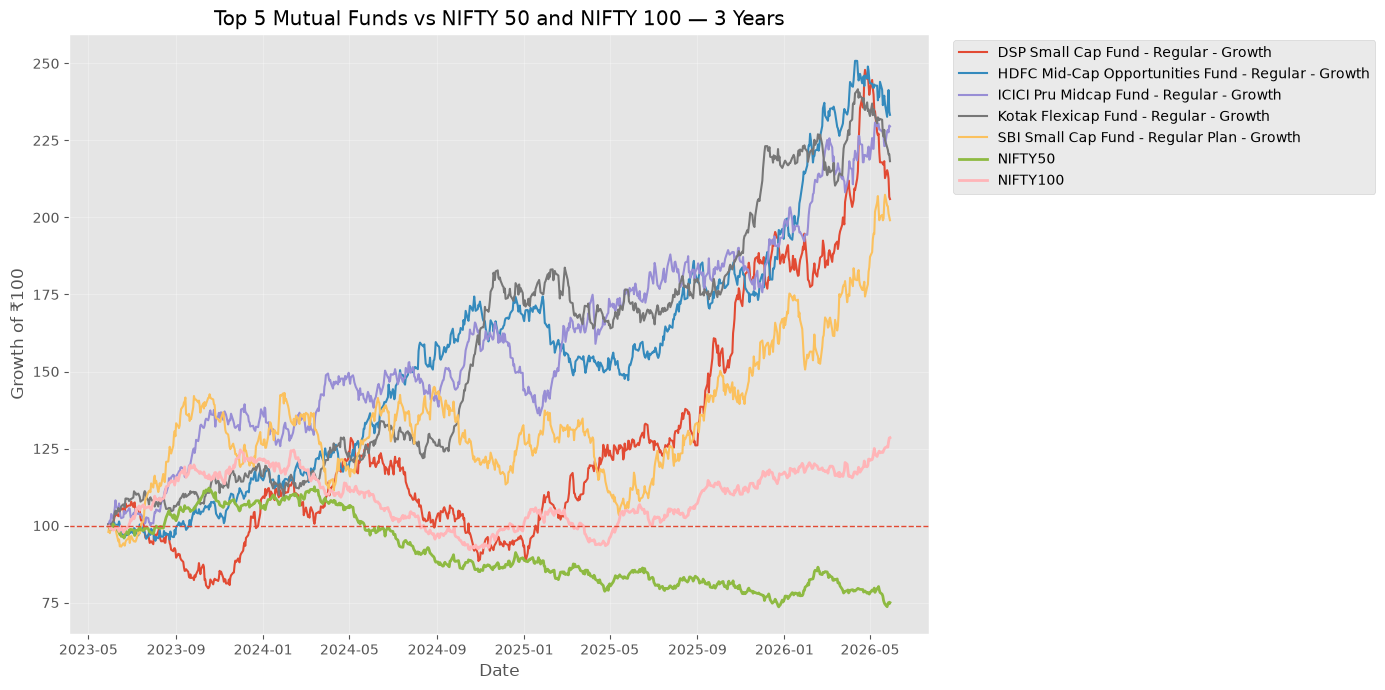

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Top 5 funds
for fund_name in fund_plot["scheme_name"].unique():

    data = fund_plot[
        fund_plot["scheme_name"] == fund_name
    ]

    plt.plot(
        data["date"],
        data["growth_index"],
        label=fund_name
    )

# NIFTY 50 and NIFTY 100
for benchmark_name in ["NIFTY50", "NIFTY100"]:

    data = benchmark_plot[
        benchmark_plot["index_name"] == benchmark_name
    ]

    plt.plot(
        data["date"],
        data["growth_index"],
        label=benchmark_name,
        linewidth=2
    )

plt.axhline(
    100,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Top 5 Mutual Funds vs NIFTY 50 and NIFTY 100 — 3 Years"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹100")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save required deliverable
plt.savefig(
    "benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [157]:
import os

print(
    "File exists:",
    os.path.exists("benchmark_comparison.png")
)

print(
    "File size:",
    os.path.getsize("benchmark_comparison.png"),
    "bytes"
)

File exists: True
File size: 730064 bytes


### Benchmark Comparison Chart

The top five funds are compared with NIFTY 50 and NIFTY 100 using the growth of an initial ₹100 investment over the latest three-year period. The resulting chart is saved as `benchmark_comparison.png`.

In [158]:
import numpy as np
import pandas as pd

tracking_error_results = []

for _, fund_row in top5.iterrows():

    fund_code = fund_row["amfi_code"]
    fund_name = fund_row["scheme_name"]

    fund_returns = fund_3yr[
        fund_3yr["amfi_code"] == fund_code
    ][
        ["date", "daily_return"]
    ].copy()

    for benchmark_name in ["NIFTY50", "NIFTY100"]:

        benchmark_returns = benchmark_3yr[
            benchmark_3yr["index_name"] == benchmark_name
        ][
            ["date", "benchmark_return"]
        ].copy()

        merged = fund_returns.merge(
            benchmark_returns,
            on="date",
            how="inner"
        ).dropna()

        active_return = (
            merged["daily_return"]
            - merged["benchmark_return"]
        )

        tracking_error = (
            active_return.std()
            * np.sqrt(252)
        )

        tracking_error_results.append({
            "amfi_code": fund_code,
            "scheme_name": fund_name,
            "benchmark": benchmark_name,
            "tracking_error_pct": tracking_error * 100,
            "observations": len(merged)
        })

tracking_error_table = pd.DataFrame(
    tracking_error_results
)

tracking_error_table

,amfi_code,scheme_name,benchmark,tracking_error_pct,observations
0,119598,SBI Small Cap Fund - Regular Plan - Growth,NIFTY50,28.1559,784
1,119598,SBI Small Cap Fund - Regular Plan - Growth,NIFTY100,28.6689,784
2,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY50,22.8447,784
3,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY100,23.2661,784
4,149324,DSP Small Cap Fund - Regular - Growth,NIFTY50,27.1768,784
5,149324,DSP Small Cap Fund - Regular - Growth,NIFTY100,27.9036,784
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY50,22.8222,784
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY100,22.4976,784
8,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY50,20.5067,784
9,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY100,20.6540,784


In [159]:
print(
    "Tracking Error Records:",
    len(tracking_error_table)
)

Tracking Error Records: 10


In [160]:
tracking_error_table = tracking_error_table[
    [
        "scheme_name",
        "benchmark",
        "tracking_error_pct",
        "observations"
    ]
].sort_values(
    ["scheme_name", "benchmark"]
)

tracking_error_table


,scheme_name,benchmark,tracking_error_pct,observations
5,DSP Small Cap Fund - Regular - Growth,NIFTY100,27.9036,784
4,DSP Small Cap Fund - Regular - Growth,NIFTY50,27.1768,784
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY100,22.4976,784
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY50,22.8222,784
3,ICICI Pru Midcap Fund - Regular - Growth,NIFTY100,23.2661,784
2,ICICI Pru Midcap Fund - Regular - Growth,NIFTY50,22.8447,784
9,Kotak Flexicap Fund - Regular - Growth,NIFTY100,20.6540,784
8,Kotak Flexicap Fund - Regular - Growth,NIFTY50,20.5067,784
1,SBI Small Cap Fund - Regular Plan - Growth,NIFTY100,28.6689,784
0,SBI Small Cap Fund - Regular Plan - Growth,NIFTY50,28.1559,784


### Tracking Error

Tracking error measures the annualized volatility of the difference between fund returns and benchmark returns. It is calculated against both NIFTY 50 and NIFTY 100 for each of the five highest-ranked funds.

In [161]:
fund_scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("Saved: fund_scorecard.csv")

Saved: fund_scorecard.csv


In [162]:
import os

print(
    "File exists:",
    os.path.exists("fund_scorecard.csv")
)

print(
    "File size:",
    os.path.getsize("fund_scorecard.csv"),
    "bytes"
)

File exists: True
File size: 6170 bytes


In [163]:
fund_scorecard.head(10)

,overall_rank,scheme_name,fund_house,category,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct,fund_score
2,1.0000,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,23.3900,0.9453,0.3034,1.4300,-28.7060,83.3750
12,2.0000,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,18.0800,1.1801,0.2926,1.3600,-18.1885,82.2500
39,3.0000,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,20.0800,0.9498,0.3006,1.5200,-31.1719,77.9375
7,4.0000,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,16.5800,1.0937,0.2720,1.3800,-16.2172,76.0000
22,5.0000,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,15.6500,1.3067,0.2733,1.4500,-12.9740,75.2500
26,6.0000,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,15.1800,0.9982,0.2608,1.3800,-20.9609,70.2500
38,7.0000,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,17.1600,1.1321,0.2660,1.6100,-17.2481,69.0000
34,8.0000,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,14.8100,1.4483,0.2698,1.4600,-11.2657,68.7500
11,9.0000,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,14.4100,1.0265,0.2119,0.8000,-12.5883,63.0000
36,10.0000,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,13.5800,1.2349,0.2827,1.6000,-16.3967,62.6875


## Fund Scorecard Export

The final composite fund scorecard for all 40 schemes is exported to `fund_scorecard.csv`.

In [164]:
alpha_beta.columns

Index(['amfi_code', 'alpha', 'beta', 'r_squared', 'observations',
       'scheme_name', 'fund_house', 'category'],
      dtype='str')

In [165]:
alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

print("Saved: alpha_beta.csv")

Saved: alpha_beta.csv


In [166]:
import os

print(
    "File exists:",
    os.path.exists("alpha_beta.csv")
)

print(
    "File size:",
    os.path.getsize("alpha_beta.csv"),
    "bytes"
)

File exists: True
File size: 5790 bytes


In [167]:
import os

print(
    "File exists:",
    os.path.exists("alpha_beta.csv")
)

print(
    "File size:",
    os.path.getsize("alpha_beta.csv"),
    "bytes"
)

File exists: True
File size: 5790 bytes


In [168]:
alpha_beta.head(10)

,amfi_code,alpha,beta,r_squared,observations,scheme_name,fund_house,category
0,100016,0.0375,-0.0583,0.0027,1149,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
1,100025,0.0428,0.0012,0.0000,1149,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt
2,100033,0.2720,0.0051,0.0000,1149,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity
3,101206,0.2140,0.0211,0.0003,1149,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
4,101207,0.1090,-0.0653,0.0011,1149,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
5,101208,0.0609,0.0003,0.0000,1149,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Debt
6,102885,0.1705,-0.0195,0.0004,1149,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity
7,102886,0.0290,-0.0421,0.0009,1149,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity
8,102887,0.1621,0.0167,0.0002,1149,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity
9,118632,0.2183,-0.0084,0.0001,1149,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity


In [169]:
import os

files = [
    "Performance_Analytics.ipynb",
    "fund_scorecard.csv",
    "alpha_beta.csv",
    "benchmark_comparison.png"
]

print("=" * 60)
print("DAY 4 DELIVERABLE CHECK")
print("=" * 60)

for file in files:
    exists = os.path.exists(file)

    if exists:
        size = os.path.getsize(file)
        print(f"✅ {file:<30} {size:,} bytes")
    else:
        print(f"❌ {file:<30} NOT FOUND")

DAY 4 DELIVERABLE CHECK
✅ Performance_Analytics.ipynb    857,584 bytes
✅ fund_scorecard.csv             6,170 bytes
✅ alpha_beta.csv                 5,790 bytes
✅ benchmark_comparison.png       730,064 bytes


In [170]:
import pandas as pd

scorecard_check = pd.read_csv("fund_scorecard.csv")
alpha_beta_check = pd.read_csv("alpha_beta.csv")

print("\nFund Scorecard rows:", len(scorecard_check))
print("Alpha-Beta rows:", len(alpha_beta_check))


Fund Scorecard rows: 40
Alpha-Beta rows: 40


import pandas as pd

scorecard_check = pd.read_csv("fund_scorecard.csv")
alpha_beta_check = pd.read_csv("alpha_beta.csv")

print("\nFund Scorecard rows:", len(scorecard_check))
print("Alpha-Beta rows:", len(alpha_beta_check))